# Import lib and dataset

In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("GPU ready")

GPU ready


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mostafaabla/garbage-classification")

print("Path to dataset files:", path)

100%|██████████| 239M/239M [00:01<00:00, 135MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mostafaabla/garbage-classification/versions/1


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
import pandas as pd
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

%matplotlib inline
plt.rcParams['figure.figsize'] = (5.0, 4.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 10
SEED = 42

# Set random seeds for reproducibility
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
import os
DATA_DIR = os.path.join(path)

print(f"Loading data from: {DATA_DIR}", 'garbage-classification')

Loading data from: /root/.cache/kagglehub/datasets/mostafaabla/garbage-classification/versions/1 garbage-classification


In [ ]:

import os

data_dir = "/kaggle/input/garbage-classification/garbage_classification"

print("=" * 70)
print("TensorFlow-based validation (this will find the corrupted files)")
print("=" * 70)

def validate_with_tensorflow(directory):
    """
    Validate ALL images using TensorFlow's decoder.
    This catches files that PIL misses.
    """
    corrupted_files = []
    checked = 0

    for root, dirs, files in os.walk(directory):
        for file in files:
            if not file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
                continue

            file_path = os.path.join(root, file)
            checked += 1

            if checked % 1000 == 0:
                print(f"  Checked {checked} files...")

            try:
                # Read file
                img_raw = tf.io.read_file(file_path)

                # Try to decode with TensorFlow (this is what will fail during training)
                img = tf.image.decode_image(img_raw, channels=3, expand_animations=False)

                # Also try to resize (sometimes this fails too)
                img_resized = tf.image.resize(img, [224, 224])

            except Exception as e:
                print(f"\n❌ FOUND PROBLEMATIC FILE: {file_path}")
                print(f"   Error: {str(e)[:100]}")
                corrupted_files.append(file_path)

                # Remove the file
                try:
                    os.remove(file_path)
                    print(f"   ✓ Removed")
                except Exception as remove_err:
                    print(f"   ✗ Could not remove: {remove_err}")

    print(f"\n✅ Checked {checked} files")
    print(f"❌ Found and removed {len(corrupted_files)} corrupted files")

    return corrupted_files

# Run TensorFlow validation
corrupted = validate_with_tensorflow(data_dir)

if len(corrupted) > 0:
    print("\nCorrupted files removed:")
    for f in corrupted:
        print(f"  - {f}")

TensorFlow-based validation (this will find the corrupted files)
  Checked 1000 files...
  Checked 2000 files...
  Checked 3000 files...
  Checked 4000 files...
  Checked 5000 files...
  Checked 6000 files...
  Checked 7000 files...
  Checked 8000 files...
  Checked 9000 files...
  Checked 10000 files...
  Checked 11000 files...
  Checked 12000 files...
  Checked 13000 files...
  Checked 14000 files...
  Checked 15000 files...

✅ Checked 15515 files
❌ Found and removed 0 corrupted files


In [ ]:
import os
import gc

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42
gc.collect()


# 1. Create Training Dataset (70%) and Validation Dataset (30%)
# Using tf.keras instead of just keras
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,      # 20% tách ra
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",       # 20% còn lại
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True
)
temp_batches = tf.data.experimental.cardinality(temp_ds)
temp_size = temp_batches.numpy()

val_size = temp_size // 2

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print(f"\nClasses: {class_names}")
print(f"Number of classes: {NUM_CLASSES}")

Found 15515 files belonging to 12 classes.
Using 12412 files for training.
Found 15515 files belonging to 12 classes.
Using 3103 files for validation.

Classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']
Number of classes: 12


Class distribution

In [ ]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)
    class_counts[class_name] = len(os.listdir(class_path))

print(class_counts)

{'battery': 945, 'biological': 985, 'brown-glass': 607, 'cardboard': 891, 'clothes': 5325, 'green-glass': 629, 'metal': 769, 'paper': 1050, 'plastic': 865, 'shoes': 1977, 'trash': 697, 'white-glass': 775}


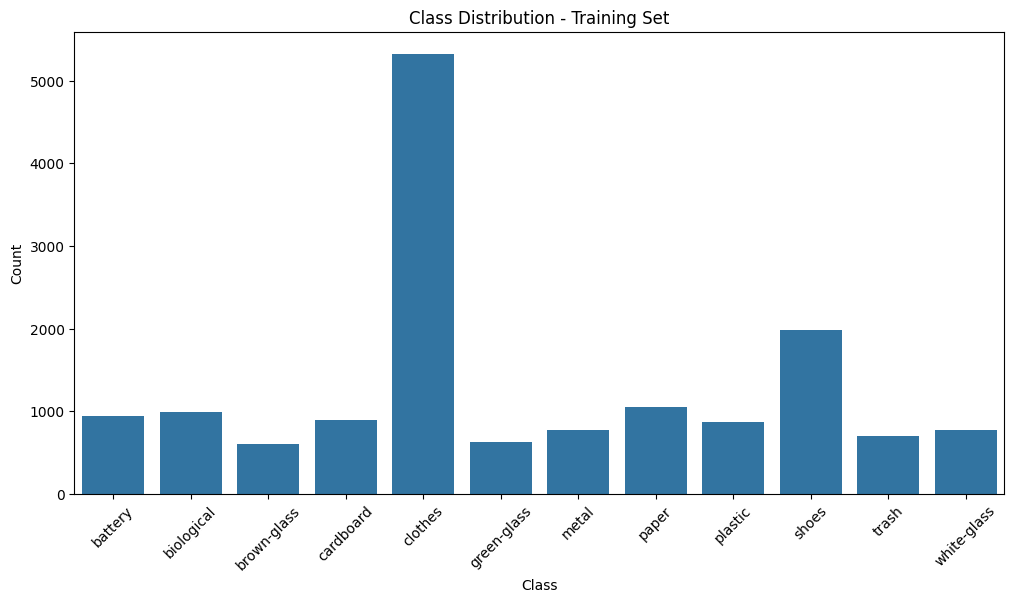

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.DataFrame({
    "Class": list(class_counts.keys()),
    "Count": list(class_counts.values())
})

plt.figure(figsize=(12,6))
sns.barplot(data=df, x="Class", y="Count")
plt.xticks(rotation=45)
plt.title("Class Distribution - Training Set")
plt.show()

Sample images

In [ ]:
import numpy as np

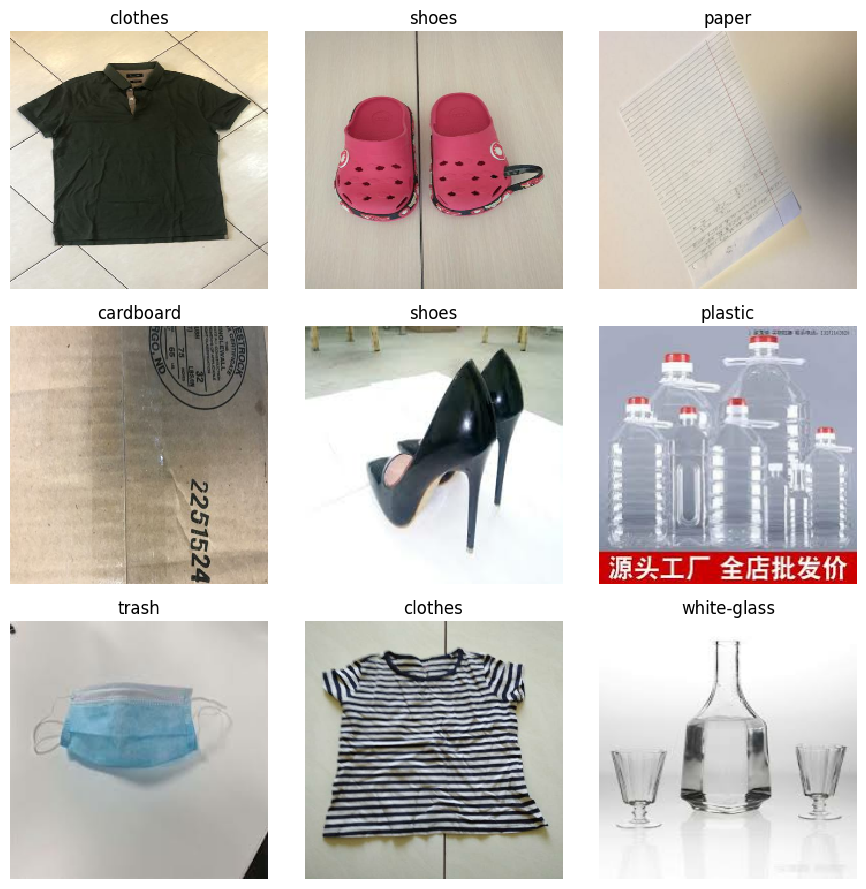

In [ ]:
# Get a batch from the training dataset
batch = next(train_ds.as_numpy_iterator())
images, labels = batch

# Display up to 9 images from the batch
num = min(9, images.shape[0])
plt.figure(figsize=(9, 9))
for idx in range(num):
    ax = plt.subplot(3, 3, idx + 1)
    img = images[idx].astype(np.uint8)
    plt.imshow(img)
    lbl_idx = labels[idx] # labels are already integer indices
    plt.title(class_names[lbl_idx]) # Corrected 'target_classs' to 'class_names'
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
batch = next(train_ds.as_numpy_iterator())
batch[0].shape

(16, 224, 224, 3)

In [ ]:
class_names = train_ds.class_names
CLOTHES_IDX = class_names.index('clothes')
SHOES_IDX = class_names.index('shoes')

STRONG_CLASSES = [
    class_names.index('battery'),
    class_names.index('brown-glass'),
    class_names.index('green-glass'),
    class_names.index('trash'),
    class_names.index('white-glass'),
    class_names.index('metal'),
]

MODERATE_CLASSES = [
    class_names.index('cardboard'),
    class_names.index('paper'),
    class_names.index('plastic'),
    class_names.index('biological'),
]

LIGHT_CLASSES = [
    SHOES_IDX
]

Normalization

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

Data Augmentation

In [ ]:
import tensorflow as tf

# ---------- STRONG ----------
strong_augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.25),
    tf.keras.layers.RandomZoom(0.3),
    tf.keras.layers.RandomContrast(0.3),
    tf.keras.layers.RandomBrightness(0.2),
])

# ---------- MODERATE ----------
moderate_augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

# ---------- LIGHT ----------
light_augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
])

# ---------- VERY LIGHT (clothes) ----------
very_light_augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
])

In [ ]:
def apply_classwise_augmentation(images, labels):

    images = tf.cast(images, tf.float32)

    def strong():
        return strong_augment(images)

    def moderate():
        return moderate_augment(images)

    def light():
        return light_augment(images)

    def very_light():
        return very_light_augment(images)

    # Tạo mask theo batch
    strong_mask = tf.reduce_any(
        tf.reduce_any([tf.equal(labels, c) for c in STRONG_CLASSES], axis=0)
    )

    moderate_mask = tf.reduce_any(
        tf.reduce_any([tf.equal(labels, c) for c in MODERATE_CLASSES], axis=0)
    )

    light_mask = tf.reduce_any(
        tf.equal(labels, SHOES_IDX)
    )

    clothes_mask = tf.reduce_any(
        tf.equal(labels, CLOTHES_IDX)
    )

    images = tf.cond(
        clothes_mask,
        very_light,
        lambda: tf.cond(
            strong_mask,
            strong,
            lambda: tf.cond(
                moderate_mask,
                moderate,
                lambda: tf.cond(
                    light_mask,
                    light,
                    lambda: images
                )
            )
        )
    )

    return images, labels

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(
    apply_classwise_augmentation,
    num_parallel_calls=AUTOTUNE
)

train_after_norm = train_ds.shuffle(200).prefetch(AUTOTUNE)
val_after_norm = val_ds.cache().prefetch(AUTOTUNE)
test_after_norm = test_ds.cache().prefetch(AUTOTUNE)

# MobinetV2 + transfer learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import mobilenet_v2
from tensorflow.keras import layers, models

In [ ]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

base_model.trainable = False



In [ ]:
input_shape = batch[0].shape[1:]
input_shape

(224, 224, 3)

In [ ]:
# import tensorflow as tf

# gpus = tf.config.list_physical_devices('GPU')
# for gpu in gpus:
#     tf.config.experimental.set_memory_growth(gpu, True)

# print(tf.config.list_physical_devices('GPU'))

# Đoạn mã này cần được di chuyển và chạy sớm hơn trong notebook,
# lý tưởng nhất là ngay sau 'import tensorflow as tf' trong ô c81a0cab,
# và trước bất kỳ hoạt động nào khác của TensorFlow sử dụng GPU.

In [ ]:
model = tf.keras.Sequential([
    layers.Input(shape=(224,224,3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(12, activation='softmax')
])

In [ ]:
model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,590,028 (9.88 MB)

 Trainable params: 331,532 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)


In [ ]:
history = model.fit(
    train_after_norm,
    epochs=30,
    validation_data=val_after_norm,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
776/776 ━━━━━━━━━━━━━━━━━━━━ 103s 79ms/step - accuracy: 0.6189 - loss: 1.2655 - val_accuracy: 0.9091 - val_loss: 0.3279
Epoch 2/30
776/776 ━━━━━━━━━━━━━━━━━━━━ 52s 52ms/step - accuracy: 0.8826 - loss: 0.3830 - val_accuracy: 0.9278 - val_loss: 0.2545
Epoch 3/30
776/776 ━━━━━━━━━━━━━━━━━━━━ 50s 53ms/step - accuracy: 0.9132 - loss: 0.2753 - val_accuracy: 0.9356 - val_loss: 0.2286
Epoch 4/30
776/776 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.9295 - loss: 0.2279 - val_accuracy: 0.9362 - val_loss: 0.2191
Epoch 5/30
776/776 ━━━━━━━━━━━━━━━━━━━━ 55s 56ms/step - accuracy: 0.9464 - loss: 0.1780 - val_accuracy: 0.9401 - val_loss: 0.2107
Epoch 6/30
776/776 ━━━━━━━━━━━━━━━━━━━━ 50s 50ms/step - accuracy: 0.9537 - loss: 0.1502 - val_accuracy: 0.9465 - val_loss: 0.1993
Epoch 7/30
776/776 ━━━━━━━━━━━━━━━━━━━━ 46s 47ms/step - accuracy: 0.9585 - loss: 0.1323 - val_accuracy: 0.9427 - val_loss: 0.2079
Epoch 8/30
776/776 ━━━━━━━━━━━━━━━━━━━━ 46s 49ms/step - accuracy: 0.9652 - loss: 0.1191 -

# Evaluate and report

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

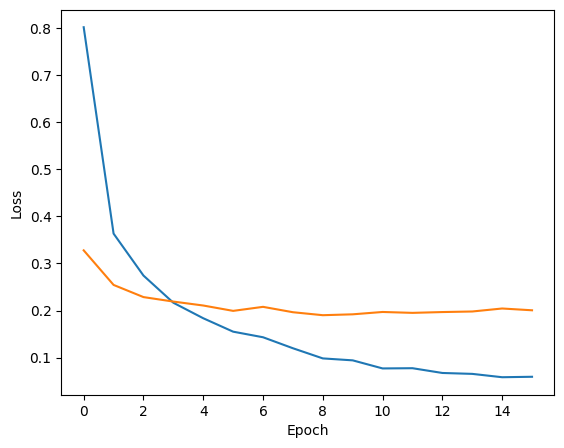

In [ ]:
plt.figure(figsize=(14, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt

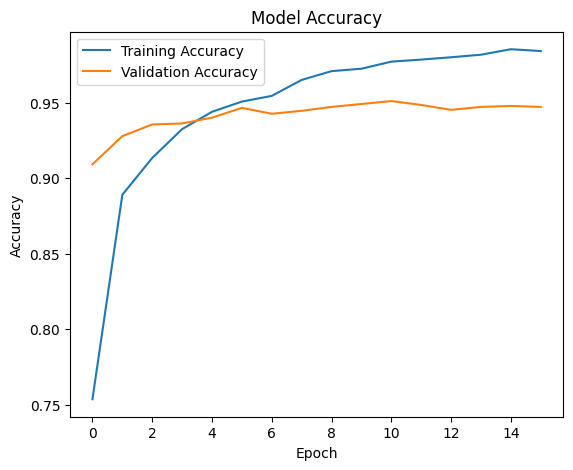

In [ ]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()


In [ ]:
scores = model.evaluate(test_after_norm)

97/97 ━━━━━━━━━━━━━━━━━━━━ 21s 175ms/step - accuracy: 0.9540 - loss: 0.1803


In [ ]:
print(f"Test Accuracy: {scores[1]*100:.2f}%")


Test Accuracy: 95.36%


In [ ]:
test_loss, test_acc = model.evaluate(test_after_norm)
print(test_acc)


97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9540 - loss: 0.1803
0.9535783529281616


97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step


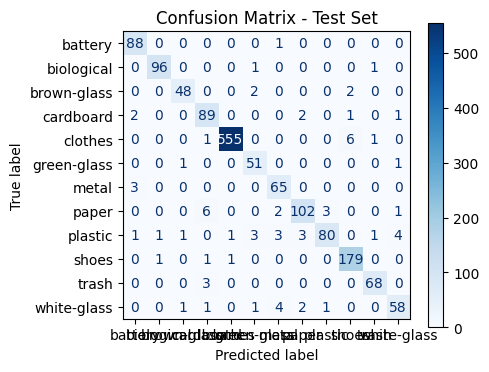

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions on test set
y_pred = model.predict(test_after_norm)
y_pred_classes = np.argmax(y_pred, axis=1)

# Extract true labels from the test dataset
test_labels = []
for _, labels in test_after_norm:
    test_labels.extend(labels.numpy())
test_labels = np.array(test_labels)

# Create confusion matrix
cm = confusion_matrix(test_labels, y_pred_classes)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(test_labels, y_pred_classes, target_names=class_names)
print(report)

              precision    recall  f1-score   support

     battery       0.94      0.99      0.96        89
  biological       0.98      0.98      0.98        98
 brown-glass       0.94      0.92      0.93        52
   cardboard       0.88      0.94      0.91        95
     clothes       1.00      0.99      0.99       563
 green-glass       0.88      0.96      0.92        53
       metal       0.87      0.96      0.91        68
       paper       0.94      0.89      0.91       114
     plastic       0.95      0.82      0.88        98
       shoes       0.95      0.98      0.97       182
       trash       0.96      0.96      0.96        71
 white-glass       0.89      0.85      0.87        68

    accuracy                           0.95      1551
   macro avg       0.93      0.94      0.93      1551
weighted avg       0.95      0.95      0.95      1551



1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step


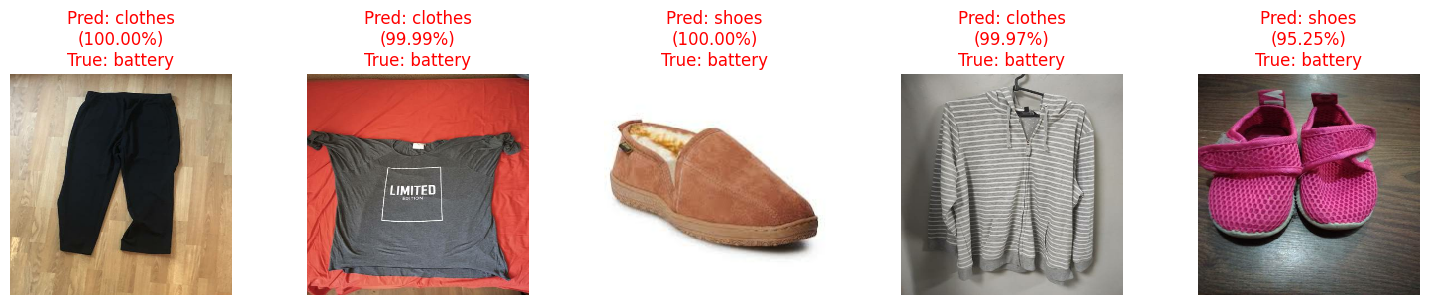

In [ ]:
# Get a single image from test set
single_batch = next(test_after_norm.as_numpy_iterator())
single_images = single_batch[0][:5]  # Get first 5 images
single_labels = single_batch[1][:5]

# Make predictions
predictions = model.predict(single_images)

# Display results
plt.figure(figsize=(15, 3))
for idx in range(5):
    ax = plt.subplot(1, 5, idx + 1)
    img = (single_images[idx] * 255).astype(np.uint8)
    plt.imshow(img)

    pred_class = np.argmax(predictions[idx])
    true_class = np.argmax(single_labels[idx])
    confidence = predictions[idx][pred_class]

    pred_name = class_names[pred_class]
    true_name = class_names[true_class]

    color = 'green' if pred_class == true_class else 'red'
    plt.title(f'Pred: {pred_name}\n({confidence:.2%})\nTrue: {true_name}', color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Create a detailed performance summary by class
performance_summary = pd.DataFrame({
    'Class': class_names,
    'Total Samples': [cm[i].sum() for i in range(len(class_names))],
    'Correct Predictions': [cm[i, i] for i in range(len(class_names))],
    'Incorrect Predictions': [cm[i].sum() - cm[i, i] for i in range(len(class_names))]
})

performance_summary['Accuracy'] = (performance_summary['Correct Predictions'] / performance_summary['Total Samples'] * 100).round(2)

print("=" * 70)
print("MODEL PERFORMANCE SUMMARY BY CLASS")
print("=" * 70)
print(performance_summary.to_string(index=False))
print("=" * 70)
print(f"\nOverall Test Accuracy: {test_acc * 100:.2f}%")
print(f"Overall Test Loss: {test_loss:.4f}")

MODEL PERFORMANCE SUMMARY BY CLASS
      Class  Total Samples  Correct Predictions  Incorrect Predictions  Accuracy
    battery             89                   88                      1     98.88
 biological             98                   96                      2     97.96
brown-glass             52                   48                      4     92.31
  cardboard             95                   89                      6     93.68
    clothes            563                  555                      8     98.58
green-glass             53                   51                      2     96.23
      metal             68                   65                      3     95.59
      paper            114                  102                     12     89.47
    plastic             98                   80                     18     81.63
      shoes            182                  179                      3     98.35
      trash             71                   68                      3    

In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive')
model.save('/content/drive/My Drive/garbage_classification_model.keras')

Mounted at /content/drive
